# AlgoTrade Pro — EMA 50/200 Backtest + ML Signal Filter
### BTC/USDT · 1H · Real Binance Data
---
**3 Fixes Applied:**
- Fix 1 → ATR multiplier 3.5x (wider stop for BTC volatility)
- Fix 2 → Min EMA spread 0.5% (avoid whipsaw signals)
- Fix 3 → RSI > 50 confirmation (only trade with momentum)
- ML    → Random Forest to filter low-quality crossovers

## Cell 1 — Imports

In [5]:
# !pip install pandas numpy matplotlib scikit-learn seaborn
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#060811','axes.facecolor':'#0b0f1a',
    'axes.edgecolor':'#1a2235','axes.labelcolor':'#8892a4',
    'axes.grid':True,'grid.color':'#1a2235','grid.linewidth':0.6,
    'text.color':'#f0f4ff','xtick.color':'#4a5568','ytick.color':'#4a5568',
    'xtick.labelsize':8,'ytick.labelsize':8,
    'legend.facecolor':'#111827','legend.edgecolor':'#1a2235',
    'legend.fontsize':9,'font.family':'monospace',
})
CYAN='#00e5c0';BLUE='#3b82f6';RED='#ff4d6d'
YELLOW='#f59e0b';PURPLE='#8b5cf6';WHITE='#f0f4ff';GRAY='#4a5568'
print('✅ Libraries imported')

✅ Libraries imported


## Cell 2 — Load Binance CSVs

In [6]:
BINANCE_COLS = ['open_time','open','high','low','close','volume',
                'close_time','quote_volume','trades','taker_buy_base','taker_buy_quote','ignore']

DATA_FOLDER = 'BTCusd_6month_1hr_data'
csv_files   = sorted(glob.glob(os.path.join(DATA_FOLDER, '*.csv')))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in '{DATA_FOLDER}/'")

print(f'Found {len(csv_files)} files:')
for f in csv_files: print(f'  {os.path.basename(f)}')

dfs    = [pd.read_csv(f, header=None, names=BINANCE_COLS) for f in csv_files]
df_raw = pd.concat(dfs, ignore_index=True)

# Auto-detect timestamp unit
sample_ts = df_raw['open_time'].iloc[0]
if   sample_ts > 1e15: df_raw['open_time'] = pd.to_datetime(df_raw['open_time'], unit='us')
elif sample_ts > 1e12: df_raw['open_time'] = pd.to_datetime(df_raw['open_time'], unit='ms')
else:                  df_raw['open_time'] = pd.to_datetime(df_raw['open_time'], unit='s')

df_raw.set_index('open_time', inplace=True)
df_raw.sort_index(inplace=True)
df_raw = df_raw[['open','high','low','close','volume']].astype(float)
df_raw = df_raw[~df_raw.index.duplicated(keep='first')]

print(f'\n✅ Loaded {len(df_raw):,} candles')
print(f'   Range : {df_raw.index[0]} → {df_raw.index[-1]}')
print(f'   Price : ${df_raw["close"].min():,.2f} → ${df_raw["close"].max():,.2f}')
df_raw.head()

Found 6 files:
  BTCUSDT-1h-2025-09.csv
  BTCUSDT-1h-2025-10.csv
  BTCUSDT-1h-2025-11.csv
  BTCUSDT-1h-2025-12.csv
  BTCUSDT-1h-2026-01.csv
  BTCUSDT-1h-2026-02.csv

✅ Loaded 4,344 candles
   Range : 2025-09-01 00:00:00 → 2026-02-28 23:00:00
   Price : $62,900.00 → $126,011.18


,open,high,low,close,volume
open_time,,,,,
2025-09-01 00:00:00,108246.36,108406.18,107631.68,108222.37,1078.82210
2025-09-01 01:00:00,108222.37,108482.98,107968.09,108150.24,471.21562
2025-09-01 02:00:00,108150.24,108197.67,107425.42,107617.05,869.81682
2025-09-01 03:00:00,107617.05,107769.94,107393.00,107660.01,786.48643
2025-09-01 04:00:00,107660.00,107759.99,107279.51,107409.10,645.82838


## Cell 3 — Indicators

In [7]:
def add_indicators(df):
    df = df.copy()
    # EMAs
    df['ema_50']  = df['close'].ewm(span=50,  adjust=False).mean()
    df['ema_200'] = df['close'].ewm(span=200, adjust=False).mean()
    # EMA spread (Fix 2 uses this)
    df['ema_spread']     = (df['ema_50'] - df['ema_200']) / df['ema_200'] * 100
    df['ema_spread_abs'] = df['ema_spread'].abs()
    df['ema_spread_ch']  = df['ema_spread'].diff()
    # RSI 14 (Fix 3 uses this)
    delta = df['close'].diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    rs    = gain.ewm(span=14,adjust=False).mean() / loss.ewm(span=14,adjust=False).mean().replace(0,np.nan)
    df['rsi'] = 100 - (100 / (1 + rs))
    # MACD
    e12 = df['close'].ewm(span=12,adjust=False).mean()
    e26 = df['close'].ewm(span=26,adjust=False).mean()
    df['macd']     = e12 - e26
    df['macd_sig'] = df['macd'].ewm(span=9,adjust=False).mean()
    df['macd_hist']= df['macd'] - df['macd_sig']
    # ATR 14 (Fix 1 uses this)
    hl  = df['high'] - df['low']
    hcp = (df['high'] - df['close'].shift()).abs()
    lcp = (df['low']  - df['close'].shift()).abs()
    df['atr']     = pd.concat([hl,hcp,lcp],axis=1).max(axis=1).ewm(span=14,adjust=False).mean()
    df['atr_pct'] = df['atr'] / df['close'] * 100
    # Bollinger Bands
    sma20 = df['close'].rolling(20).mean()
    std20 = df['close'].rolling(20).std()
    df['bb_upper'] = sma20 + 2*std20
    df['bb_lower'] = sma20 - 2*std20
    df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / sma20 * 100
    df['bb_pos']   = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])
    # Volume
    df['vol_sma20'] = df['volume'].rolling(20).mean()
    df['vol_ratio'] = df['volume'] / df['vol_sma20']
    # Momentum
    df['ret_1h']  = df['close'].pct_change(1)  * 100
    df['ret_4h']  = df['close'].pct_change(4)  * 100
    df['ret_24h'] = df['close'].pct_change(24) * 100
    # Crossover signals
    df['cross_up']   = (df['ema_50'] > df['ema_200']) & (df['ema_50'].shift() <= df['ema_200'].shift())
    df['cross_down'] = (df['ema_50'] < df['ema_200']) & (df['ema_50'].shift() >= df['ema_200'].shift())
        
        # ── ADX (14) — Trend Strength ──
    plus_dm  = df['high'].diff()
    minus_dm = df['low'].diff(-1).abs()

    plus_dm  = plus_dm.where((plus_dm > minus_dm) & (plus_dm > 0), 0.0)
    minus_dm = minus_dm.where((minus_dm > plus_dm) & (minus_dm > 0), 0.0)

    tr  = pd.concat([
        df['high'] - df['low'],
        (df['high'] - df['close'].shift()).abs(),
        (df['low']  - df['close'].shift()).abs()
    ], axis=1).max(axis=1)

    atr14    = tr.ewm(span=14, adjust=False).mean()
    plus_di  = 100 * plus_dm.ewm(span=14,  adjust=False).mean() / atr14
    minus_di = 100 * minus_dm.ewm(span=14, adjust=False).mean() / atr14
    dx       = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)

    df['adx']      = dx.ewm(span=14, adjust=False).mean()
    df['plus_di']  = plus_di
    df['minus_di'] = minus_di
    
    return df.dropna()

df = add_indicators(df_raw)
print(f'✅ Indicators done | Candles: {len(df):,}')
print(f'   Golden Crosses : {df["cross_up"].sum()}')
print(f'   Death Crosses  : {df["cross_down"].sum()}')
df[['close','ema_50','ema_200','rsi','ema_spread','atr']].tail(5)

✅ Indicators done | Candles: 4,320
   Golden Crosses : 14
   Death Crosses  : 15


,close,ema_50,ema_200,rsi,ema_spread,atr
open_time,,,,,,
2026-02-28 19:00:00,66362.01,65685.413550,66491.148008,71.652533,-1.211792,803.081891
2026-02-28 20:00:00,66959.62,65735.382430,66495.809421,76.564238,-1.143571,824.146972
2026-02-28 21:00:00,66723.22,65774.121158,66498.072213,70.952909,-1.088680,805.879376
2026-02-28 22:00:00,67103.64,65826.259152,66504.097763,74.432243,-1.019243,851.919459
2026-02-28 23:00:00,66973.26,65871.239578,66508.766044,71.065960,-0.958560,801.832864


In [9]:
# checking adx

# Quick check — run in a new cell
print("ADX values at each Golden/Death Cross:")
print(f"\n{'Time':<25} {'Direction':<10} {'ADX':>8} {'Trade?':>10}")
print("-"*60)

for ts, row in df[df['cross_up'] | df['cross_down']].iterrows():
    direction = 'LONG'  if row['cross_up']   else 'SHORT'
    adx       = float(row['adx'])
    trade_ok  = '✅ YES' if adx > 25 else '❌ NO (ranging)'
    print(f"{str(ts):<25} {direction:<10} {adx:>8.2f} {trade_ok:>10}")

ADX values at each Golden/Death Cross:

Time                      Direction       ADX     Trade?
------------------------------------------------------------
2025-09-22 02:00:00       SHORT         79.33      ✅ YES
2025-09-29 22:00:00       LONG          26.92      ✅ YES
2025-10-10 20:00:00       SHORT         87.91      ✅ YES
2025-10-24 12:00:00       LONG          14.98 ❌ NO (ranging)
2025-10-30 09:00:00       SHORT         82.99      ✅ YES
2025-11-10 23:00:00       LONG          54.69      ✅ YES
2025-11-11 19:00:00       SHORT         70.21      ✅ YES
2025-11-27 09:00:00       LONG          19.17 ❌ NO (ranging)
2025-12-01 06:00:00       SHORT         70.93      ✅ YES
2025-12-03 04:00:00       LONG          22.67 ❌ NO (ranging)
2025-12-06 12:00:00       SHORT         68.02      ✅ YES
2025-12-08 08:00:00       LONG          36.04      ✅ YES
2025-12-13 08:00:00       SHORT         61.52      ✅ YES
2025-12-22 05:00:00       LONG          36.76      ✅ YES
2025-12-23 14:00:00       SHORT 

## Cell 4 — Price Chart

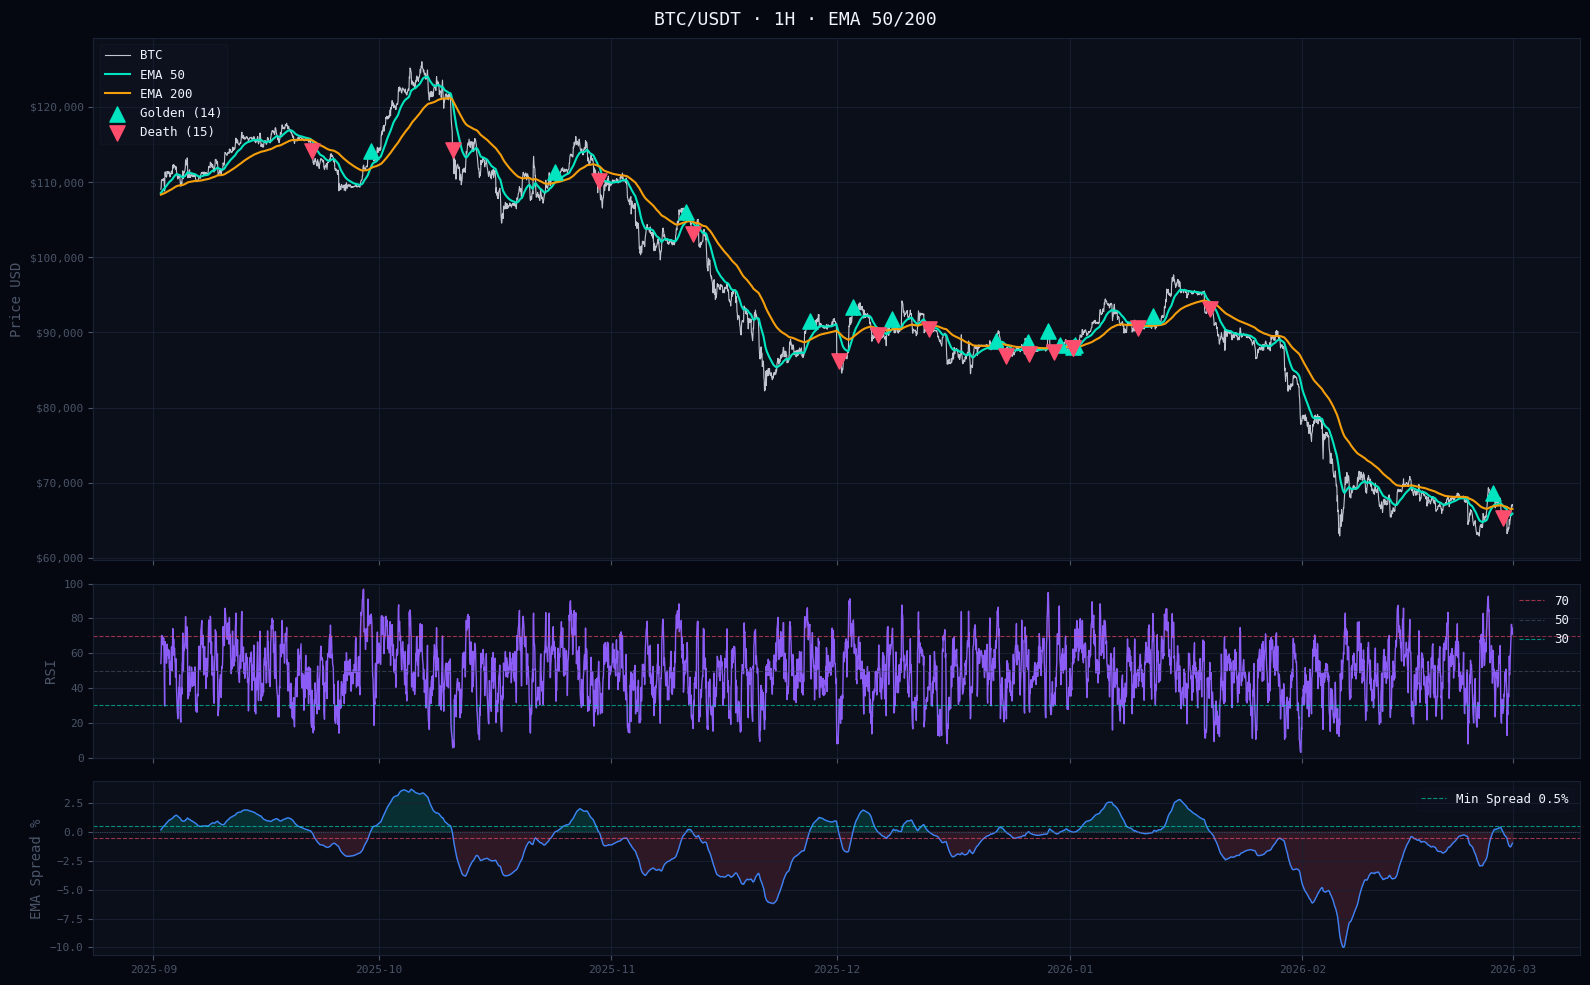

In [8]:
fig, axes = plt.subplots(3,1,figsize=(16,10),sharex=True,
                          gridspec_kw={'height_ratios':[3,1,1]})
fig.patch.set_facecolor('#060811')
fig.suptitle('BTC/USDT · 1H · EMA 50/200', color=WHITE, fontsize=13, y=0.98)

ax1=axes[0]
ax1.plot(df.index,df['close'],  color=WHITE, lw=0.8,alpha=0.8,label='BTC')
ax1.plot(df.index,df['ema_50'], color=CYAN,  lw=1.5,label='EMA 50')
ax1.plot(df.index,df['ema_200'],color=YELLOW,lw=1.5,label='EMA 200')
gc=df[df['cross_up']]; dc=df[df['cross_down']]
ax1.scatter(gc.index,gc['close'],marker='^',color=CYAN, s=120,zorder=5,label=f'Golden ({len(gc)})')
ax1.scatter(dc.index,dc['close'],marker='v',color=RED,  s=120,zorder=5,label=f'Death ({len(dc)})')
ax1.set_ylabel('Price USD',color=GRAY)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'${x:,.0f}'))
ax1.legend(loc='upper left',framealpha=0.3)

ax2=axes[1]
ax2.plot(df.index,df['rsi'],color=PURPLE,lw=1.0)
ax2.axhline(70,color=RED, lw=0.8,ls='--',alpha=0.6,label='70')
ax2.axhline(50,color=GRAY,lw=0.8,ls='--',alpha=0.6,label='50')
ax2.axhline(30,color=CYAN,lw=0.8,ls='--',alpha=0.6,label='30')
ax2.fill_between(df.index,df['rsi'],70,where=(df['rsi']>=70),alpha=0.15,color=RED)
ax2.fill_between(df.index,df['rsi'],30,where=(df['rsi']<=30),alpha=0.15,color=CYAN)
ax2.set_ylim(0,100);ax2.set_ylabel('RSI',color=GRAY)
ax2.legend(loc='upper right',framealpha=0.2)

ax3=axes[2]
ax3.plot(df.index,df['ema_spread'],color=BLUE,lw=1.0)
ax3.axhline(0,  color=GRAY,lw=0.6,ls=':')
ax3.axhline(0.5,color=CYAN,lw=0.8,ls='--',alpha=0.6,label='Min Spread 0.5%')
ax3.axhline(-0.5,color=RED,lw=0.8,ls='--',alpha=0.6)
ax3.fill_between(df.index,df['ema_spread'],0,where=(df['ema_spread']>=0),alpha=0.15,color=CYAN)
ax3.fill_between(df.index,df['ema_spread'],0,where=(df['ema_spread']<0), alpha=0.15,color=RED)
ax3.set_ylabel('EMA Spread %',color=GRAY)
ax3.legend(loc='upper right',framealpha=0.2)

plt.tight_layout()
plt.show()

## Cell 5 — Backtest Engine (V1 Original + V2 Fixed)

In [9]:
def run_backtest(df, initial_capital=10_000.0, risk_per_trade=0.02,
                 atr_sl_mult=3.5, commission=0.001,
                 min_ema_spread=0.03, rsi_min=50.0,
                 rr_ratio=2.0, adx_min=25.0,
                 trail_trigger=0.66,
                 signal_filter=None, label='Backtest'):

    capital     = initial_capital
    position    = 0.0
    entry_price = 0.0
    entry_time  = None
    stop_loss   = 0.0
    take_profit = 0.0
    direction   = None
    sl_moved_be = False
    trades      = []
    equity_curve= []
    in_trade    = False
    skipped     = {'spread':0,'rsi':0,'adx':0,'ml':0}

    for ts, row in df.iterrows():
        price = float(row['close'])

        # Equity
        if direction == 'long':
            equity = capital + position * price
        elif direction == 'short':
            equity = capital + position * (entry_price - price)
        else:
            equity = capital
        equity_curve.append({'timestamp':ts,'equity':equity,'price':price})

        # ── Trailing Stop → Move SL to Breakeven ──
        if in_trade and not sl_moved_be:
            be_price = entry_price
            if direction == 'long':
                tp_dist       = take_profit - entry_price
                trigger_price = entry_price + tp_dist * trail_trigger
                if price >= trigger_price:
                    stop_loss   = be_price
                    sl_moved_be = True
                    print(f'   🔒 LONG  BE triggered at ${price:,.2f} → SL → ${stop_loss:,.2f}')
            elif direction == 'short':
                tp_dist       = entry_price - take_profit
                trigger_price = entry_price - tp_dist * trail_trigger
                if price <= trigger_price:
                    stop_loss   = be_price
                    sl_moved_be = True
                    print(f'   🔒 SHORT BE triggered at ${price:,.2f} → SL → ${stop_loss:,.2f}')

        # ── Stop Loss / Take Profit Check ──
        if in_trade:
            sl_hit = tp_hit = False
            if direction == 'long':
                if price <= stop_loss:   sl_hit = True
                if price >= take_profit: tp_hit = True
            elif direction == 'short':
                if price >= stop_loss:   sl_hit = True
                if price <= take_profit: tp_hit = True

            if sl_hit or tp_hit:
                reason = 'STOP LOSS' if sl_hit else 'TAKE PROFIT'
                if sl_hit and sl_moved_be:
                    reason = 'BREAKEVEN'
                if direction == 'long':
                    pnl = (price - entry_price) * position
                else:
                    pnl = (entry_price - price) * position
                comm    = price * position * commission
                capital = equity - comm
                trades.append({
                    'entry_time':  entry_time,  'exit_time':   ts,
                    'entry_price': entry_price, 'exit_price':  price,
                    'direction':   direction,
                    'stop_loss':   stop_loss,   'take_profit': take_profit,
                    'pnl':         pnl - comm,  'exit_reason': reason,
                    'sl_moved_be': sl_moved_be, 'position':    position,
                    'duration_h':  (ts - entry_time).total_seconds() / 3600
                })
                position    = 0.0
                in_trade    = False
                direction   = None
                sl_moved_be = False

        # ── Golden Cross → Close SHORT + Open LONG ──
        if bool(row['cross_up']):

            # Close short first
            if in_trade and direction == 'short':
                pnl     = (entry_price - price) * position
                comm    = price * position * commission
                capital = equity - comm
                trades.append({
                    'entry_time':  entry_time,  'exit_time':   ts,
                    'entry_price': entry_price, 'exit_price':  price,
                    'direction':   'short',
                    'stop_loss':   stop_loss,   'take_profit': take_profit,
                    'pnl':         pnl - comm,  'exit_reason': 'SIGNAL',
                    'sl_moved_be': sl_moved_be, 'position':    position,
                    'duration_h':  (ts - entry_time).total_seconds() / 3600
                })
                position    = 0.0
                in_trade    = False
                direction   = None
                sl_moved_be = False

            # Filters for LONG
            spread_ok = float(row['ema_spread_abs']) >= min_ema_spread
            rsi_ok    = float(row['rsi']) >= rsi_min
            adx_ok    = float(row['adx']) >= adx_min
            ml_ok     = True
            if signal_filter is not None:
                ml_ok = bool(signal_filter.get(ts, False))
            if not spread_ok: skipped['spread'] += 1
            if not rsi_ok:    skipped['rsi']    += 1
            if not adx_ok:    skipped['adx']    += 1
            if not ml_ok:     skipped['ml']     += 1

            # Open LONG
            if spread_ok and rsi_ok and adx_ok and ml_ok and not in_trade:
                atr         = float(row['atr'])
                sl_dist     = atr * atr_sl_mult
                stop_loss   = price - sl_dist
                take_profit = price + sl_dist * rr_ratio
                risk_amt    = capital * risk_per_trade
                position    = min(risk_amt / sl_dist, (capital * 0.95) / price)
                cost        = position * price * (1 + commission)
                if cost <= capital and position > 0:
                    capital     -= cost
                    entry_price  = price
                    entry_time   = ts
                    direction    = 'long'
                    in_trade     = True
                    sl_moved_be  = False

        # ── Death Cross → Close LONG + Open SHORT ──
        elif bool(row['cross_down']):

            # Close long first
            if in_trade and direction == 'long':
                pnl     = (price - entry_price) * position
                comm    = price * position * commission
                capital = equity - comm
                trades.append({
                    'entry_time':  entry_time,  'exit_time':   ts,
                    'entry_price': entry_price, 'exit_price':  price,
                    'direction':   'long',
                    'stop_loss':   stop_loss,   'take_profit': take_profit,
                    'pnl':         pnl - comm,  'exit_reason': 'SIGNAL',
                    'sl_moved_be': sl_moved_be, 'position':    position,
                    'duration_h':  (ts - entry_time).total_seconds() / 3600
                })
                position    = 0.0
                in_trade    = False
                direction   = None
                sl_moved_be = False

            # Filters for SHORT
            spread_ok = float(row['ema_spread_abs']) >= min_ema_spread
            adx_ok    = float(row['adx']) >= adx_min

            # Open SHORT
            if spread_ok and adx_ok and not in_trade:
                atr         = float(row['atr'])
                sl_dist     = atr * atr_sl_mult
                stop_loss   = price + sl_dist
                take_profit = price - sl_dist * rr_ratio
                risk_amt    = capital * risk_per_trade
                position    = min(risk_amt / sl_dist, (capital * 0.95) / price)
                cost        = position * price * commission
                if capital > cost and position > 0:
                    capital     -= cost
                    entry_price  = price
                    entry_time   = ts
                    direction    = 'short'
                    in_trade     = True
                    sl_moved_be  = False

    # ── Close open trade at end ──
    if in_trade:
        price = float(df['close'].iloc[-1])
        if direction == 'long':
            pnl = (price - entry_price) * position
        else:
            pnl = (entry_price - price) * position
        comm    = price * position * commission
        capital = equity_curve[-1]['equity'] - comm
        trades.append({
            'entry_time':  entry_time,  'exit_time':   df.index[-1],
            'entry_price': entry_price, 'exit_price':  price,
            'direction':   direction,
            'stop_loss':   stop_loss,   'take_profit': take_profit,
            'pnl':         pnl - comm,  'exit_reason': 'END',
            'sl_moved_be': sl_moved_be, 'position':    position,
            'duration_h':  (df.index[-1] - entry_time).total_seconds() / 3600
        })

    trades_df = pd.DataFrame(trades)
    equity_df = pd.DataFrame(equity_curve).set_index('timestamp')

    # ── Print Summary ──
    print(f'\n✅ [{label}]  RR={rr_ratio}:1  ATR={atr_sl_mult}x  ADX>{adx_min}  Trail@{trail_trigger*100:.0f}%')
    if not trades_df.empty:
        longs  = trades_df[trades_df['direction']=='long']
        shorts = trades_df[trades_df['direction']=='short']
        wins   = trades_df[trades_df['pnl']>0]
        tps    = trades_df[trades_df['exit_reason']=='TAKE PROFIT']
        sls    = trades_df[trades_df['exit_reason']=='STOP LOSS']
        bes    = trades_df[trades_df['exit_reason']=='BREAKEVEN']
        sigs   = trades_df[trades_df['exit_reason']=='SIGNAL']
        ret    = (capital - initial_capital) / initial_capital * 100
        print(f'   Trades       : {len(trades_df)}  (L:{len(longs)}  S:{len(shorts)})')
        print(f'   Win Rate     : {len(wins)/len(trades_df)*100:.1f}%')
        print(f'   Take Profit  : {len(tps)} ✅')
        print(f'   Breakeven    : {len(bes)} 🔒')
        print(f'   Stop Loss    : {len(sls)} ❌')
        print(f'   Signal Exit  : {len(sigs)} 🔄')
        print(f'   Skipped-Spread: {skipped["spread"]}')
        print(f'   Skipped-RSI  : {skipped["rsi"]}')
        print(f'   Skipped-ADX  : {skipped["adx"]}')
        print(f'   Skipped-ML   : {skipped["ml"]}')
    else:
        ret = 0
        print('   No trades generated')
    print(f'   Capital      : ${initial_capital:,.2f} → ${capital:,.2f}')
    print(f'   Return       : {ret:+.2f}%')

    return {'trades':trades_df,'equity':equity_df,
            'final_capital':capital,'initial_capital':initial_capital,'label':label}


# ── V1: Original (no filters) ──
result_v1 = run_backtest(
    df, atr_sl_mult=2.0, min_ema_spread=0.0,
    rsi_min=0.0, adx_min=0.0, rr_ratio=1.0,
    trail_trigger=1.0, label='V1 Original'
)

# ── V2: All filters + ADX 25 ──
result_v2 = run_backtest(
    df, atr_sl_mult=3.5, min_ema_spread=0.03,
    rsi_min=50.0, adx_min=25.0, rr_ratio=2.0,
    trail_trigger=0.66, label='V2 ADX25+Trail'
)

# ── V3: Stricter ADX 30 ──
result_v3 = run_backtest(
    df, atr_sl_mult=3.5, min_ema_spread=0.03,
    rsi_min=50.0, adx_min=30.0, rr_ratio=2.0,
    trail_trigger=0.66, label='V3 ADX30+Trail'
)

   🔒 SHORT BE triggered at $112,800.77 → SL → $114,187.81
   🔒 SHORT BE triggered at $111,095.37 → SL → $114,266.82
   🔒 LONG  BE triggered at $113,286.09 → SL → $111,297.01
   🔒 SHORT BE triggered at $107,627.16 → SL → $110,171.69
   🔒 SHORT BE triggered at $84,677.87 → SL → $86,234.16
   🔒 SHORT BE triggered at $88,220.53 → SL → $89,581.19
   🔒 SHORT BE triggered at $89,853.69 → SL → $90,458.19
   🔒 LONG  BE triggered at $89,829.60 → SL → $88,831.34
   🔒 LONG  BE triggered at $88,839.04 → SL → $88,316.37
   🔒 SHORT BE triggered at $92,062.61 → SL → $93,065.84
   🔒 SHORT BE triggered at $63,216.01 → SL → $65,314.76

✅ [V1 Original]  RR=1.0:1  ATR=2.0x  ADX>0.0  Trail@100%
   Trades       : 29  (L:14  S:15)
   Win Rate     : 37.9%
   Take Profit  : 11 ✅
   Breakeven    : 0 🔒
   Stop Loss    : 15 ❌
   Signal Exit  : 3 🔄
   Skipped-Spread: 0
   Skipped-RSI  : 0
   Skipped-ADX  : 0
   Skipped-ML   : 0
   Capital      : $10,000.00 → $8,815.55
   Return       : -11.84%
   🔒 SHORT BE trigger

In [ ]:
#cell 5 remaining output 

# ── V2: All filters + ADX 25 ──
result_v2 = run_backtest(
    df, atr_sl_mult=3.5, min_ema_spread=0.03,
    rsi_min=50.0, adx_min=25.0, rr_ratio=2.0,
    trail_trigger=0.66, label='V2 ADX25+Trail'
)

# ── V3: Stricter ADX 30 ──
result_v3 = run_backtest(
    df, atr_sl_mult=3.5, min_ema_spread=0.03,
    rsi_min=50.0, adx_min=30.0, rr_ratio=2.0,
    trail_trigger=0.66, label='V3 ADX30+Trail'
)

   🔒 SHORT BE triggered at $107,838.01 → SL → $114,266.82
   🔒 SHORT BE triggered at $104,215.76 → SL → $110,171.69
   🔒 SHORT BE triggered at $99,659.99 → SL → $103,126.39

✅ [V2 ADX25+Trail]  RR=2.0:1  ATR=3.5x  ADX>25.0  Trail@66%
   Trades       : 6  (L:0  S:6)
   Win Rate     : 50.0%
   Take Profit  : 3 ✅
   Breakeven    : 0 🔒
   Stop Loss    : 2 ❌
   Signal Exit  : 0 🔄
   Skipped-Spread: 11
   Skipped-RSI  : 0
   Skipped-ADX  : 6
   Skipped-ML   : 0
   Capital      : $10,000.00 → $10,500.19
   Return       : +5.00%
   🔒 SHORT BE triggered at $107,838.01 → SL → $114,266.82
   🔒 SHORT BE triggered at $104,215.76 → SL → $110,171.69
   🔒 SHORT BE triggered at $99,659.99 → SL → $103,126.39

✅ [V3 ADX30+Trail]  RR=2.0:1  ATR=3.5x  ADX>30.0  Trail@66%
   Trades       : 6  (L:0  S:6)
   Win Rate     : 50.0%
   Take Profit  : 3 ✅
   Breakeven    : 0 🔒
   Stop Loss    : 2 ❌
   Signal Exit  : 0 🔄
   Skipped-Spread: 11
   Skipped-RSI  : 0
   Skipped-ADX  : 9
   Skipped-ML   : 0
   Capital   

In [8]:
# Detailed trade analysis with trailing stop
r = run_backtest(df, atr_sl_mult=3.5, min_ema_spread=0.03,
                 rsi_min=50.0, rr_ratio=2.0,
                 trail_trigger=0.66,
                 label='Trail@66% Analysis')

trades = r['trades']
print(f"\n{'─'*95}")
print(f"  {'#':<3} {'Dir':<6} {'Entry':>12} {'Exit':>12} {'SL':>12} {'TP':>12} {'PnL':>10} {'Reason':<12} {'BE?'}")
print(f"{'─'*95}")
for i, (_, t) in enumerate(trades.iterrows()):
    icon = '✅' if t['pnl'] > 0 else ('🔒' if t['exit_reason']=='BREAKEVEN' else '❌')
    be   = '🔒 YES' if t['sl_moved_be'] else 'NO'
    sign = '+' if t['pnl'] > 0 else ''
    print(f"  {icon}{i+1:<3} {t['direction']:<6} "
          f"${t['entry_price']:>11,.0f} ${t['exit_price']:>11,.0f} "
          f"${t['stop_loss']:>11,.0f} ${t['take_profit']:>11,.0f} "
          f"{sign}${t['pnl']:>8,.0f}  {t['exit_reason']:<12} {be}")
print(f"{'─'*95}")
print(f"\nSummary:")
print(f"  Take Profits : {len(trades[trades['exit_reason']=='TAKE PROFIT'])} ✅")
print(f"  Breakevens   : {len(trades[trades['exit_reason']=='BREAKEVEN'])} 🔒")
print(f"  Stop Losses  : {len(trades[trades['exit_reason']=='STOP LOSS'])} ❌")
print(f"  Signal Exits : {len(trades[trades['exit_reason']=='SIGNAL'])} 🔄")
print(f"  Total PnL    : ${trades['pnl'].sum():,.2f}")
print(f"  Return       : {(r['final_capital']-10000)/10000*100:+.2f}%")

   🔒 SHORT BE triggered at $107,838.01 → SL → $114,266.82
   🔒 SHORT BE triggered at $104,215.76 → SL → $110,171.69
   🔒 SHORT BE triggered at $99,659.99 → SL → $103,126.39

✅ [Trail@66% Analysis]  RR=2.0:1  ATR=3.5x  ADX>25.0  Trail@66%
   Trades       : 6  (L:0  S:6)
   Win Rate     : 50.0%
   Take Profit  : 3 ✅
   Breakeven    : 0 🔒
   Stop Loss    : 2 ❌
   Signal Exit  : 0 🔄
   Skipped-Spread: 11
   Skipped-RSI  : 0
   Skipped-ADX  : 6
   Skipped-ML   : 0
   Capital      : $10,000.00 → $10,500.19
   Return       : +5.00%

───────────────────────────────────────────────────────────────────────────────────────────────
  #   Dir           Entry         Exit           SL           TP        PnL Reason       BE?
───────────────────────────────────────────────────────────────────────────────────────────────
  ✅1   short  $    114,267 $    104,531 $    114,267 $    104,570 +$     397  TAKE PROFIT  🔒 YES
  ✅2   short  $    110,172 $    102,258 $    110,172 $    102,881 +$     445  TAKE PRO

In [15]:
# Debug trailing stop
cross_down_times = df[df['cross_down']].index
print("First few Death Cross entries (SHORT trades):")
for ts in cross_down_times[:4]:
    row = df.loc[ts]
    price     = float(row['close'])
    atr       = float(row['atr'])
    sl_dist   = atr * 3.5
    sl        = price + sl_dist          # SHORT sl above entry
    tp        = price - sl_dist * 2.0   # SHORT tp below entry
    trigger50 = price - (price - tp) * 0.50
    trigger66 = price - (price - tp) * 0.66

    print(f"\n  {ts}")
    print(f"  Entry      : ${price:,.2f}")
    print(f"  Stop Loss  : ${sl:,.2f}  (above entry)")
    print(f"  Take Profit: ${tp:,.2f}  (below entry)")
    print(f"  Trail@50%  : ${trigger50:,.2f}  (price must DROP here)")
    print(f"  Trail@66%  : ${trigger66:,.2f}  (price must DROP here)")
    print(f"  Breakeven  : ${price:,.2f}  (SL moves here)")

First few Death Cross entries (SHORT trades):

  2025-09-22 02:00:00
  Entry      : $114,187.81
  Stop Loss  : $115,540.66  (above entry)
  Take Profit: $111,482.10  (below entry)
  Trail@50%  : $112,834.96  (price must DROP here)
  Trail@66%  : $112,402.04  (price must DROP here)
  Breakeven  : $114,187.81  (SL moves here)

  2025-10-10 20:00:00
  Entry      : $114,266.82
  Stop Loss  : $119,115.12  (above entry)
  Take Profit: $104,570.22  (below entry)
  Trail@50%  : $109,418.52  (price must DROP here)
  Trail@66%  : $107,867.07  (price must DROP here)
  Breakeven  : $114,266.82  (SL moves here)

  2025-10-30 09:00:00
  Entry      : $110,171.69
  Stop Loss  : $113,816.82  (above entry)
  Take Profit: $102,881.43  (below entry)
  Trail@50%  : $106,526.56  (price must DROP here)
  Trail@66%  : $105,360.12  (price must DROP here)
  Breakeven  : $110,171.69  (SL moves here)

  2025-11-11 19:00:00
  Entry      : $103,126.39
  Stop Loss  : $105,610.20  (above entry)
  Take Profit: $98,158

In [13]:
# Grid search ATR × RR combinations
import itertools

print(f"{'ATR':>6} {'RR':>6} {'Trades':>8} {'WR%':>8} {'TPs':>6} {'SLs':>6} {'Return':>10} {'Final $':>12}")
print("-"*70)

best_return = -999
best_params = {}

for atr_mult, rr in itertools.product([2.0, 2.5, 3.0, 3.5, 4.0], [1.5, 2.0, 2.5, 3.0]):
    r = run_backtest(df,
                     atr_sl_mult    = atr_mult,
                     min_ema_spread = 0.03,
                     rsi_min        = 50.0,
                     rr_ratio       = rr,
                     label          = f'ATR{atr_mult}_RR{rr}')
    t  = r['trades']
    if t.empty: continue
    wr  = len(t[t['pnl']>0]) / len(t) * 100
    tps = len(t[t['exit_reason']=='TAKE PROFIT'])
    sls = len(t[t['exit_reason']=='STOP LOSS'])
    ret = (r['final_capital'] - 10000) / 10000 * 100

    print(f"{atr_mult:>6.1f} {rr:>6.1f} {len(t):>8} {wr:>7.1f}% {tps:>6} {sls:>6} {ret:>9.2f}%  ${r['final_capital']:>10,.2f}")

    if ret > best_return:
        best_return = ret
        best_params = {'atr': atr_mult, 'rr': rr, 'return': ret, 'final': r['final_capital']}

print("-"*70)
print(f"\n🏆 Best combination: ATR={best_params['atr']}x  RR={best_params['rr']}:1")
print(f"   Return : {best_params['return']:+.2f}%")
print(f"   Final  : ${best_params['final']:,.2f}")

   ATR     RR   Trades      WR%    TPs    SLs     Return      Final $
----------------------------------------------------------------------

✅ [ATR2.0_RR1.5]  RR=1.5:1  ATR=2.0x
   Total Trades    : 9  (L:3 S:6)
   Win Rate        : 33.3%
   Take Profits    : 3  ✅
   Stop Losses     : 6  ❌
   Initial Capital : $10,000.00
   Final Capital   : $9,726.51
   Return          : -2.73%
   2.0    1.5        9    33.3%      3      6     -2.73%  $  9,726.51

✅ [ATR2.0_RR2.0]  RR=2.0:1  ATR=2.0x
   Total Trades    : 9  (L:3 S:6)
   Win Rate        : 22.2%
   Take Profits    : 2  ✅
   Stop Losses     : 7  ❌
   Initial Capital : $10,000.00
   Final Capital   : $9,366.75
   Return          : -6.33%
   2.0    2.0        9    22.2%      2      7     -6.33%  $  9,366.75

✅ [ATR2.0_RR2.5]  RR=2.5:1  ATR=2.0x
   Total Trades    : 9  (L:3 S:6)
   Win Rate        : 22.2%
   Take Profits    : 2  ✅
   Stop Losses     : 7  ❌
   Initial Capital : $10,000.00
   Final Capital   : $9,605.31
   Return          : 

In [9]:


# Find optimal EMA spread threshold
print(f"{'Threshold':>12} {'Trades':>8} {'Final $':>12} {'Return':>10} {'Signals Allowed'}")
print("-"*70)

for threshold in [0.0, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]:
    r = run_backtest(df, atr_sl_mult=3.5, min_ema_spread=threshold,
                     rsi_min=50.0, label=f'spread_{threshold}')
    pnl = r['final_capital'] - r['initial_capital']
    ret = (r['final_capital'] - r['initial_capital']) / r['initial_capital'] * 100
    n   = len(r['trades'])
    
    # Count how many signals pass
    passed = sum(1 for _, row in df[df['cross_up']].iterrows() 
                 if float(row['ema_spread_abs']) >= threshold)
    
    print(f"{threshold:>12.3f} {n:>8} {r['final_capital']:>12,.2f} {ret:>9.2f}%  {passed}/14 signals")

   Threshold   Trades      Final $     Return Signals Allowed
----------------------------------------------------------------------

✅ [spread_0.0]
   Trades          : 14
   Skipped-Spread  : 0 (EMA spread < 0.0%)
   Skipped-RSI     : 0 (RSI < 50.0)
   Skipped-ML      : 0 (ML rejected)
   Initial capital : $10,000.00
   Final capital   : $7,848.94
       0.000       14     7,848.94    -21.51%  14/14 signals

✅ [spread_0.005]
   Trades          : 12
   Skipped-Spread  : 2 (EMA spread < 0.005%)
   Skipped-RSI     : 0 (RSI < 50.0)
   Skipped-ML      : 0 (ML rejected)
   Initial capital : $10,000.00
   Final capital   : $7,923.83
       0.005       12     7,923.83    -20.76%  12/14 signals

✅ [spread_0.01]
   Trades          : 10
   Skipped-Spread  : 4 (EMA spread < 0.01%)
   Skipped-RSI     : 0 (RSI < 50.0)
   Skipped-ML      : 0 (ML rejected)
   Initial capital : $10,000.00
   Final capital   : $7,905.33
       0.010       10     7,905.33    -20.95%  10/14 signals

✅ [spread_0.02]
   T

In [ ]:
#Debugging finding errors

# Check why V2 has 0 trades
cross_up_df = df[df['cross_up']].copy()

print(f"Total Golden Cross signals: {len(cross_up_df)}")
print()
print(f"{'Time':<25} {'EMA Spread%':>12} {'Spread OK':>10} {'RSI':>8} {'RSI OK':>8}")
print("-"*70)

for ts, row in cross_up_df.iterrows():
    spread     = float(row['ema_spread_abs'])
    rsi        = float(row['rsi'])
    spread_ok  = spread >= 0.5
    rsi_ok     = rsi >= 50.0
    print(f"{str(ts):<25} {spread:>12.4f} {str(spread_ok):>10} {rsi:>8.2f} {str(rsi_ok):>8}")

Total Golden Cross signals: 14

Time                       EMA Spread%  Spread OK      RSI   RSI OK
----------------------------------------------------------------------
2025-09-29 22:00:00             0.0293      False    77.30     True
2025-10-24 12:00:00             0.0236      False    63.43     True
2025-11-10 23:00:00             0.0283      False    54.93     True
2025-11-27 09:00:00             0.0505      False    75.74     True
2025-12-03 04:00:00             0.0661      False    77.32     True
2025-12-08 08:00:00             0.0247      False    70.07     True
2025-12-22 05:00:00             0.0189      False    62.85     True
2025-12-26 12:00:00             0.0167      False    54.46     True
2025-12-29 04:00:00             0.0698      False    94.87     True
2025-12-30 17:00:00             0.0034      False    56.55     True
2026-01-01 11:00:00             0.0007      False    62.39     True
2026-01-01 17:00:00             0.0081      False    73.73     True
2026-01-12 02

## Cell 6 — Performance Metrics

In [15]:
def calc_metrics(result):
    trades = result['trades']
    eq     = result['equity']['equity']
    init   = result['initial_capital']
    final  = result['final_capital']

    empty = {'total_trades':0,'winning_trades':0,'losing_trades':0,'win_rate':0,
             'total_pnl':0,'total_return':0,'avg_win':0,'avg_loss':0,
             'profit_factor':0,'max_drawdown':0,'sharpe_ratio':0,
             'calmar_ratio':0,'expectancy':0,'best_trade':0,
             'worst_trade':0,'avg_duration_h':0,'sl_hits':0,
             'long_pnl':0,'short_pnl':0}
    if trades.empty: return empty

    wins   = trades[trades['pnl'] > 0]
    losses = trades[trades['pnl'] <= 0]
    longs  = trades[trades['direction'] == 'long']
    shorts = trades[trades['direction'] == 'short']

    total_pnl    = trades['pnl'].sum()
    win_rate     = len(wins) / len(trades) * 100
    avg_win      = wins['pnl'].mean()       if len(wins)   else 0
    avg_loss     = losses['pnl'].mean()     if len(losses) else 0
    gross_profit = wins['pnl'].sum()        if len(wins)   else 0
    gross_loss   = abs(losses['pnl'].sum()) if len(losses) else 1
    pf           = gross_profit / gross_loss if gross_loss > 0 else np.inf
    total_ret    = (final - init) / init * 100
    roll_max     = eq.cummax()
    max_dd       = ((eq - roll_max) / roll_max * 100).min()
    rets         = eq.pct_change().dropna()
    sharpe       = (rets.mean() / rets.std()) * np.sqrt(8760) if rets.std() > 0 else 0
    calmar       = (total_ret / abs(max_dd)) if max_dd != 0 else 0
    expectancy   = (win_rate/100 * avg_win) + ((1 - win_rate/100) * avg_loss)

    return {
        'total_trades':   len(trades),
        'winning_trades': len(wins),
        'losing_trades':  len(losses),
        'win_rate':       win_rate,
        'total_pnl':      total_pnl,
        'total_return':   total_ret,
        'avg_win':        avg_win,
        'avg_loss':       avg_loss,
        'profit_factor':  pf,
        'max_drawdown':   max_dd,
        'sharpe_ratio':   sharpe,
        'calmar_ratio':   calmar,
        'expectancy':     expectancy,
        'best_trade':     trades['pnl'].max(),
        'worst_trade':    trades['pnl'].min(),
        'avg_duration_h': trades['duration_h'].mean(),
        'sl_hits':        len(trades[trades['exit_reason'] == 'STOP LOSS']),
        'long_pnl':       longs['pnl'].sum()  if len(longs)  else 0,
        'short_pnl':      shorts['pnl'].sum() if len(shorts) else 0,
        'long_trades':    len(longs),
        'short_trades':   len(shorts),
        'long_wr':        len(longs[longs['pnl']>0])  / len(longs)  * 100 if len(longs)  else 0,
        'short_wr':       len(shorts[shorts['pnl']>0]) / len(shorts) * 100 if len(shorts) else 0,
    }

m1 = calc_metrics(result_v1)
m2 = calc_metrics(result_v2)
m3 = calc_metrics(result_v3)

print('=' * 75)
print(f"  {'METRIC':<24} {'V1 Long+Short':>15} {'V2 Fixed':>15}{'V3 ML-Filter':>15}")
print('=' * 75)
for label, key, fmt in [
    ('Total Trades',    'total_trades',   '{:.0f}'),
    ('Long Trades',     'long_trades',    '{:.0f}'),
    ('Short Trades',    'short_trades',   '{:.0f}'),
    ('Win Rate %',      'win_rate',       '{:.1f}%'),
    ('Long Win Rate',   'long_wr',        '{:.1f}%'),
    ('Short Win Rate',  'short_wr',       '{:.1f}%'),
    ('Total PnL',       'total_pnl',      '${:.2f}'),
    ('Long PnL',        'long_pnl',       '${:.2f}'),
    ('Short PnL',       'short_pnl',      '${:.2f}'),
    ('Total Return',    'total_return',   '{:.2f}%'),
    ('Sharpe Ratio',    'sharpe_ratio',   '{:.2f}'),
    ('Max Drawdown',    'max_drawdown',   '{:.2f}%'),
    ('Profit Factor',   'profit_factor',  '{:.2f}'),
    ('Avg Win',         'avg_win',        '${:.2f}'),
    ('Avg Loss',        'avg_loss',       '${:.2f}'),
    ('Expectancy',      'expectancy',     '${:.2f}'),
    ('SL Hits',         'sl_hits',        '{:.0f}'),
    ('Avg Duration',    'avg_duration_h', '{:.1f}h'),
]:
    v1 = fmt.format(m1.get(key, 0))
    v2 = fmt.format(m2.get(key, 0))
    v3 = fmt.format(m3.get(key, 0))
    print(f"  {label:<24} {v1:>15} {v2:>15}{v3:>15}")
print('=' * 58)

  METRIC                     V1 Long+Short        V2 Fixed   V3 ML-Filter
  Total Trades                          29               6              6
  Long Trades                           14               0              0
  Short Trades                          15               6              6
  Win Rate %                         37.9%           50.0%          50.0%
  Long Win Rate                      21.4%            0.0%           0.0%
  Short Win Rate                     53.3%           50.0%          50.0%
  Total PnL                       $-920.40         $545.17        $545.17
  Long PnL                       $-1374.09           $0.00          $0.00
  Short PnL                        $453.69         $545.17        $545.17
  Total Return                     -11.84%           5.00%          5.00%
  Sharpe Ratio                       -2.21            0.99           0.99
  Max Drawdown                     -19.85%          -8.11%         -8.11%
  Profit Factor                       

## Cell 7 — Full Trade Log

In [11]:
def print_trade_log(result, metrics):
    trades=result['trades']; label=result['label']
    if trades.empty:
        print(f'[{label}] No trades generated'); return
    print(f'\n{"-"*102}')
    print(f'  TRADE LOG — {label}')
    print(f'{"-"*102}')
    print(f"  {'#':<4} {'Entry':>20} {'Exit':>20} {'Entry$':>10} {'Exit$':>10} {'PnL':>10} {'Reason':<12} {'Hrs':>6}")
    print(f'  {"-"*98}')
    for i,(_,t) in enumerate(trades.iterrows()):
        sign='+' if t['pnl']>0 else ''
        icon='✅' if t['pnl']>0 else '❌'
        print(f"  {icon}{i+1:<3} {str(t['entry_time']):>20} {str(t['exit_time']):>20} "
              f"${t['entry_price']:>9,.0f} ${t['exit_price']:>9,.0f} "
              f"{sign}${t['pnl']:>8,.0f}  {t['exit_reason']:<12} {t['duration_h']:>5.1f}h")
    print(f'  {"-"*98}')
    print(f"  Total PnL: ${trades['pnl'].sum():,.2f}  |  "
          f"Win Rate: {metrics['win_rate']:.1f}%  |  "
          f"Best: +${metrics['best_trade']:,.0f}  |  "
          f"Worst: ${metrics['worst_trade']:,.0f}")

print_trade_log(result_v1, m1)
print_trade_log(result_v2, m2)


------------------------------------------------------------------------------------------------------
  TRADE LOG — V1 Original
------------------------------------------------------------------------------------------------------
  #                   Entry                 Exit     Entry$      Exit$        PnL Reason          Hrs
  --------------------------------------------------------------------------------------------------
  ✅1    2025-09-22 02:00:00  2025-09-22 06:00:00 $  114,188 $  112,801 +$     106  TAKE PROFIT    4.0h
  ❌2    2025-09-29 22:00:00  2025-09-30 09:00:00 $  114,190 $  112,782 $    -128  STOP LOSS     11.0h
  ✅3    2025-10-10 20:00:00  2025-10-11 01:00:00 $  114,267 $  111,095 +$     220  TAKE PROFIT    5.0h
  ✅4    2025-10-24 12:00:00  2025-10-26 11:00:00 $  111,297 $  113,286 +$     163  TAKE PROFIT   47.0h
  ✅5    2025-10-30 09:00:00  2025-10-30 13:00:00 $  110,172 $  107,627 +$     217  TAKE PROFIT    4.0h
  ❌6    2025-11-10 23:00:00  2025-11-11 12:00:00 $

## Cell 8 — Equity Curve Comparison

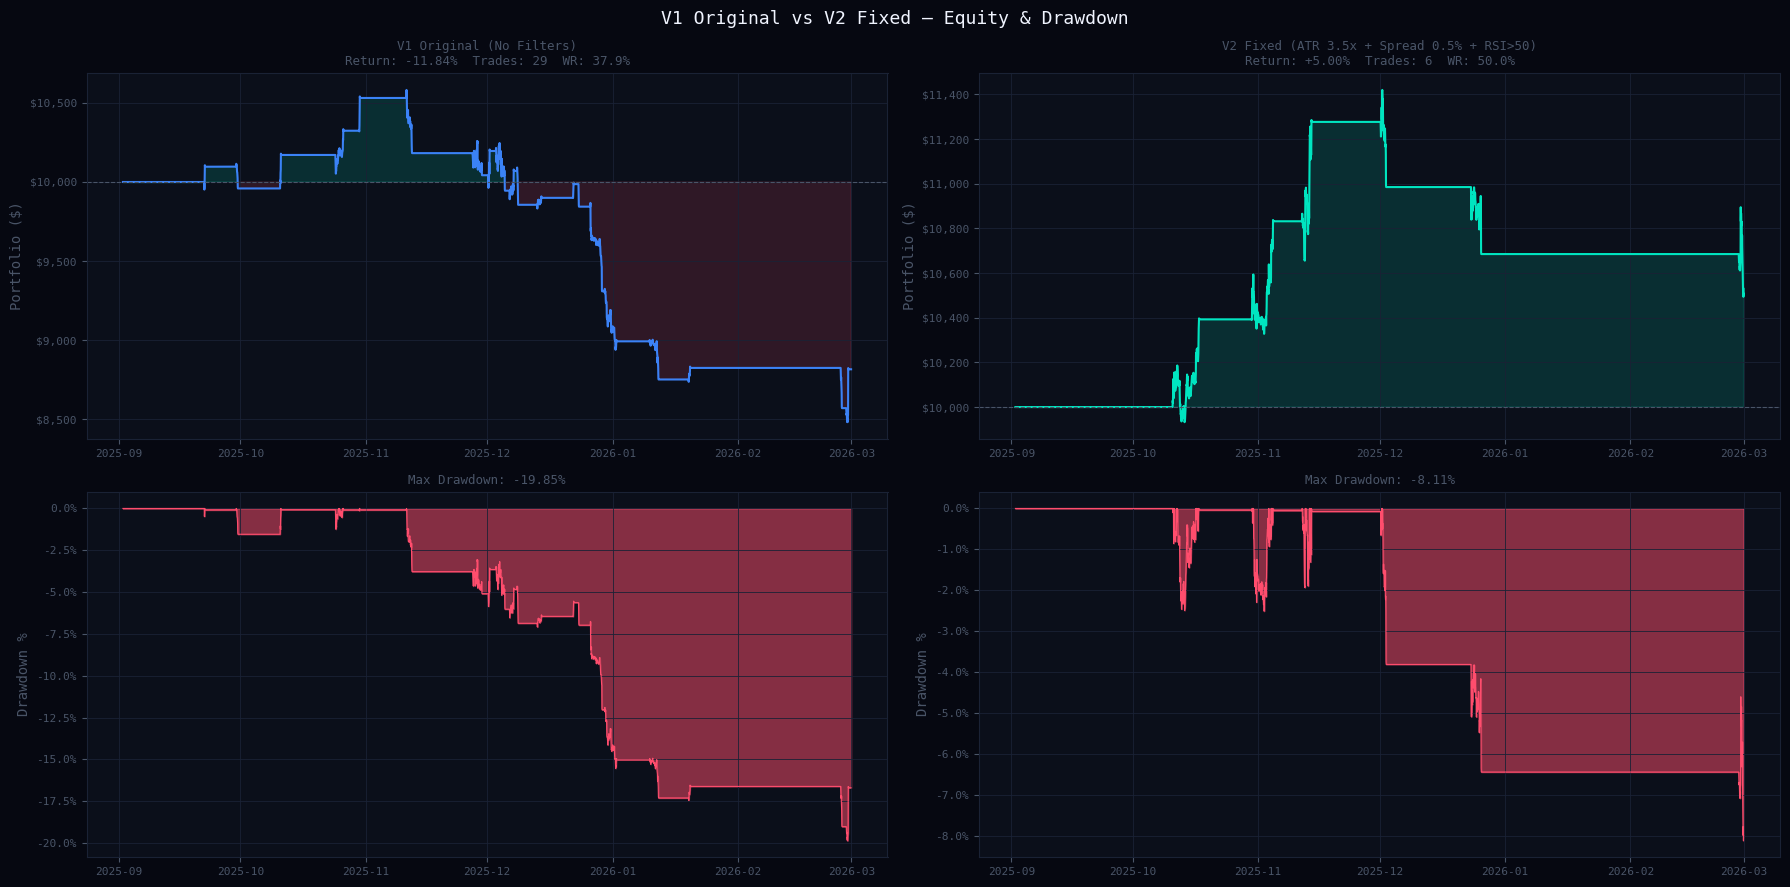

In [17]:
fig,axes=plt.subplots(2,2,figsize=(18,9))
fig.patch.set_facecolor('#060811')
fig.suptitle('V1 Original vs V2 Fixed — Equity & Drawdown',color=WHITE,fontsize=13)

for col,(res,met,color,title) in enumerate([
    (result_v1,m1,BLUE, 'V1 Original (No Filters)'),
    (result_v2,m2,CYAN, 'V2 Fixed (ATR 3.5x + Spread 0.5% + RSI>50)'),
]):
    eq=res['equity']['equity']
    ax=axes[0][col]
    ax.plot(eq.index,eq.values,color=color,lw=1.5)
    ax.fill_between(eq.index,eq.values,res['initial_capital'],
                    where=(eq.values>=res['initial_capital']),alpha=0.15,color=CYAN)
    ax.fill_between(eq.index,eq.values,res['initial_capital'],
                    where=(eq.values<res['initial_capital']),alpha=0.15,color=RED)
    ax.axhline(res['initial_capital'],color=GRAY,lw=0.8,ls='--')
    ax.set_title(f'{title}\nReturn: {met["total_return"]:+.2f}%  Trades: {met["total_trades"]}  WR: {met["win_rate"]:.1f}%',
                 color=GRAY,fontsize=9)
    ax.set_ylabel('Portfolio ($)',color=GRAY)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'${x:,.0f}'))

    ax2=axes[1][col]
    roll_max=eq.cummax(); dd=(eq-roll_max)/roll_max*100
    ax2.fill_between(dd.index,dd.values,0,color=RED,alpha=0.5)
    ax2.plot(dd.index,dd.values,color=RED,lw=0.8)
    ax2.set_title(f'Max Drawdown: {met["max_drawdown"]:.2f}%',color=GRAY,fontsize=9)
    ax2.set_ylabel('Drawdown %',color=GRAY)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'{x:.1f}%'))

plt.tight_layout()
plt.show()

## Cell 9 — ML Feature Engineering

In [18]:
FEATURE_COLS = ['ema_spread','ema_spread_abs','ema_spread_ch','rsi','macd',
                'macd_hist','atr_pct','bb_width','bb_pos','vol_ratio',
                'ret_1h','ret_4h','ret_24h']

def build_ml_dataset(df, trades):
    if trades.empty: return pd.DataFrame(), pd.Series(dtype=int)
    rows=[]; labels=[]
    for _,trade in trades.iterrows():
        et=trade['entry_time']
        if et not in df.index: continue
        row=df.loc[et]
        feat={c:float(row[c]) for c in FEATURE_COLS}
        feat['rsi_vs_50']   = float(row['rsi'])-50
        feat['macd_vs_sig'] = float(row['macd'])-float(row['macd_sig'])
        rows.append(feat)
        labels.append(1 if trade['pnl']>0 else 0)
    return pd.DataFrame(rows), pd.Series(labels,name='profitable')

# Use V1 trades for more training samples
X,y = build_ml_dataset(df, result_v1['trades'])
print(f'✅ ML Dataset: {len(X)} samples')
if len(y)>0:
    print(f'   Profitable : {y.sum()} ({y.mean()*100:.1f}%)')
    print(f'   Losing     : {(1-y).sum()} ({(1-y).mean()*100:.1f}%)')
X

✅ ML Dataset: 29 samples
   Profitable : 11 (37.9%)
   Losing     : 18 (62.1%)


,ema_spread,ema_spread_abs,ema_spread_ch,rsi,macd,macd_hist,atr_pct,bb_width,bb_pos,vol_ratio,ret_1h,ret_4h,ret_24h,rsi_vs_50,macd_vs_sig
0,-0.015738,0.015738,-0.036230,17.421552,-302.086899,-138.253530,0.338503,1.658364,-0.105983,3.095280,-0.074943,-1.169381,-1.299110,-32.578448,-138.253530
1,0.029336,0.029336,0.064281,77.303155,886.181122,54.251662,0.372260,3.796834,0.789215,0.672012,0.011456,0.158777,2.011193,27.303155,54.251662
2,-0.119147,0.119147,-0.164301,6.446313,-1374.432163,-640.142426,1.212275,7.153867,-0.176845,3.349437,-2.052674,-3.332151,-5.649675,-43.553687,-640.142426
3,0.023555,0.023555,0.036803,63.427999,486.787722,-6.752840,0.588190,2.171509,0.747336,2.723715,0.207732,0.179310,1.953072,13.427999,-6.752840
4,-0.048241,0.048241,-0.050659,43.868842,-601.243654,78.768354,0.945312,2.926571,0.288819,0.543220,-0.490108,-0.069480,-2.480871,-6.131158,78.768354
5,0.028287,0.028287,0.037536,54.932718,347.296537,-94.394505,0.629016,1.676628,0.557203,0.578782,-0.048716,0.182521,1.230074,4.932718,-94.394505
6,-0.039636,0.039636,-0.045038,21.240814,-574.350570,-234.368418,0.688147,4.147932,0.101056,0.446795,-0.265645,-0.318590,-2.543613,-28.759186,-234.368418
7,0.050491,0.050491,0.086637,75.740981,950.539837,42.964621,0.595353,6.298216,0.734074,0.744670,0.076127,0.653123,5.455094,25.740981,42.964621
8,-0.045709,0.045709,-0.125564,18.696966,-1333.376578,-522.530037,0.823039,10.813672,0.148611,0.943688,0.271020,-0.562866,-5.131560,-31.303034,-522.530037
9,0.066081,0.066081,0.134255,77.323494,1417.189178,167.754865,0.871935,9.376560,0.830163,0.882916,0.791653,1.856958,7.349557,27.323494,167.754865


## Cell 10 — Train ML Models

In [19]:
if len(X) < 6:
    print('⚠️ Need at least 6 trades to train ML model')
else:
    split=max(1,int(len(X)*0.8))
    X_train,X_test=X.iloc[:split],X.iloc[split:]
    y_train,y_test=y.iloc[:split],y.iloc[split:]
    print(f'Train: {len(X_train)} | Test: {len(X_test)}')

    models={
        'Random Forest':Pipeline([('sc',StandardScaler()),
            ('m',RandomForestClassifier(n_estimators=100,max_depth=4,random_state=42))]),
        'Gradient Boosting':Pipeline([('sc',StandardScaler()),
            ('m',GradientBoostingClassifier(n_estimators=100,max_depth=3,random_state=42))]),
        'Logistic Regression':Pipeline([('sc',StandardScaler()),
            ('m',LogisticRegression(random_state=42,max_iter=1000))]),
    }

    results_ml={}; cv_folds=min(3,len(X)//2)
    print('\n'+'='*50+'\n  ML MODEL RESULTS\n'+'='*50)
    for name,pipe in models.items():
        pipe.fit(X_train,y_train)
        y_pred=pipe.predict(X_test) if len(X_test)>0 else np.array([])
        acc=accuracy_score(y_test,y_pred) if len(y_pred)>0 else 0
        cv=cross_val_score(pipe,X,y,cv=cv_folds,scoring='accuracy')
        results_ml[name]={'pipeline':pipe,'accuracy':acc,'cv_mean':cv.mean(),'cv_std':cv.std()}
        print(f'  {name}')
        print(f'    Test Accuracy : {acc*100:.1f}%')
        print(f'    CV Accuracy   : {cv.mean()*100:.1f}% ± {cv.std()*100:.1f}%\n')

    best_name =max(results_ml,key=lambda k:results_ml[k]['cv_mean'])
    best_model=results_ml[best_name]['pipeline']
    print(f'🏆 Best: {best_name} (CV: {results_ml[best_name]["cv_mean"]*100:.1f}%)')

Train: 23 | Test: 6

  ML MODEL RESULTS
  Random Forest
    Test Accuracy : 83.3%
    CV Accuracy   : 61.5% ± 12.0%

  Gradient Boosting
    Test Accuracy : 66.7%
    CV Accuracy   : 41.5% ± 2.1%

  Logistic Regression
    Test Accuracy : 50.0%
    CV Accuracy   : 44.4% ± 18.1%

🏆 Best: Random Forest (CV: 61.5%)


## Cell 11 — Feature Importance

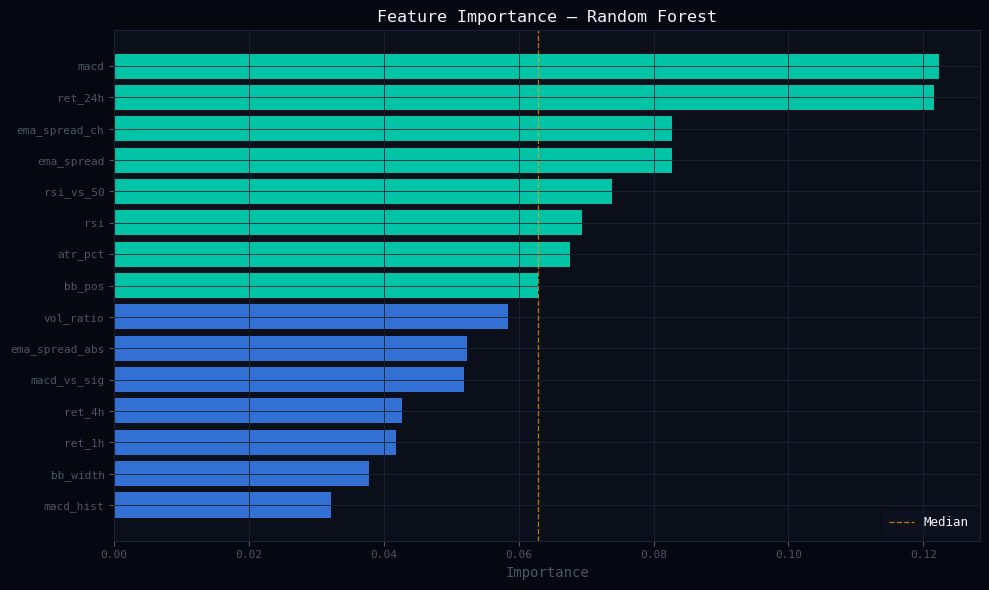

Top 5 features:
macd             0.122288
ret_24h          0.121577
ema_spread_ch    0.082777
ema_spread       0.082702
rsi_vs_50        0.073759


In [20]:
if len(X)>=6:
    rf  =results_ml['Random Forest']['pipeline'].named_steps['m']
    imps=pd.Series(rf.feature_importances_,index=X.columns).sort_values(ascending=True)
    fig,ax=plt.subplots(figsize=(10,6));fig.patch.set_facecolor('#060811')
    colors=[CYAN if v>=imps.median() else BLUE for v in imps.values]
    ax.barh(imps.index,imps.values,color=colors,alpha=0.85)
    ax.axvline(imps.median(),color=YELLOW,lw=1,ls='--',alpha=0.7,label='Median')
    ax.set_title('Feature Importance — Random Forest',color=WHITE,fontsize=12)
    ax.set_xlabel('Importance',color=GRAY)
    ax.legend(framealpha=0.3)
    plt.tight_layout(); plt.show()
    print('Top 5 features:')
    print(imps.sort_values(ascending=False).head(5).to_string())

## Cell 12 — V3: Fixed + ML Backtest

In [21]:
if len(X)>=6:
    cross_times=df[df['cross_up']].index
    all_feats=[]
    for ts in cross_times:
        row=df.loc[ts]
        feat={c:float(row[c]) for c in FEATURE_COLS}
        feat['rsi_vs_50']   = float(row['rsi'])-50
        feat['macd_vs_sig'] = float(row['macd'])-float(row['macd_sig'])
        all_feats.append(feat)

    X_all     =pd.DataFrame(all_feats,index=cross_times)
    ml_preds  =best_model.predict(X_all)
    ml_filter =pd.Series(ml_preds.astype(bool),index=cross_times)

    print(f'ML approved {ml_filter.sum()}/{len(ml_filter)} signals ({ml_filter.mean()*100:.1f}%)')

    result_v3=run_backtest(df,atr_sl_mult=3.5,min_ema_spread=0.5,
                           rsi_min=50.0,signal_filter=ml_filter,label='V3 Fixed+ML')
    m3=calc_metrics(result_v3)
    print_trade_log(result_v3,m3)

ML approved 2/14 signals (14.3%)

✅ [V3 Fixed+ML]  RR=2.0:1  ATR=3.5x  ADX>25.0  Trail@66%
   No trades generated
   Capital      : $10,000.00 → $10,000.00
   Return       : +0.00%
[V3 Fixed+ML] No trades generated


## Cell 13 — Final 3-Way Comparison

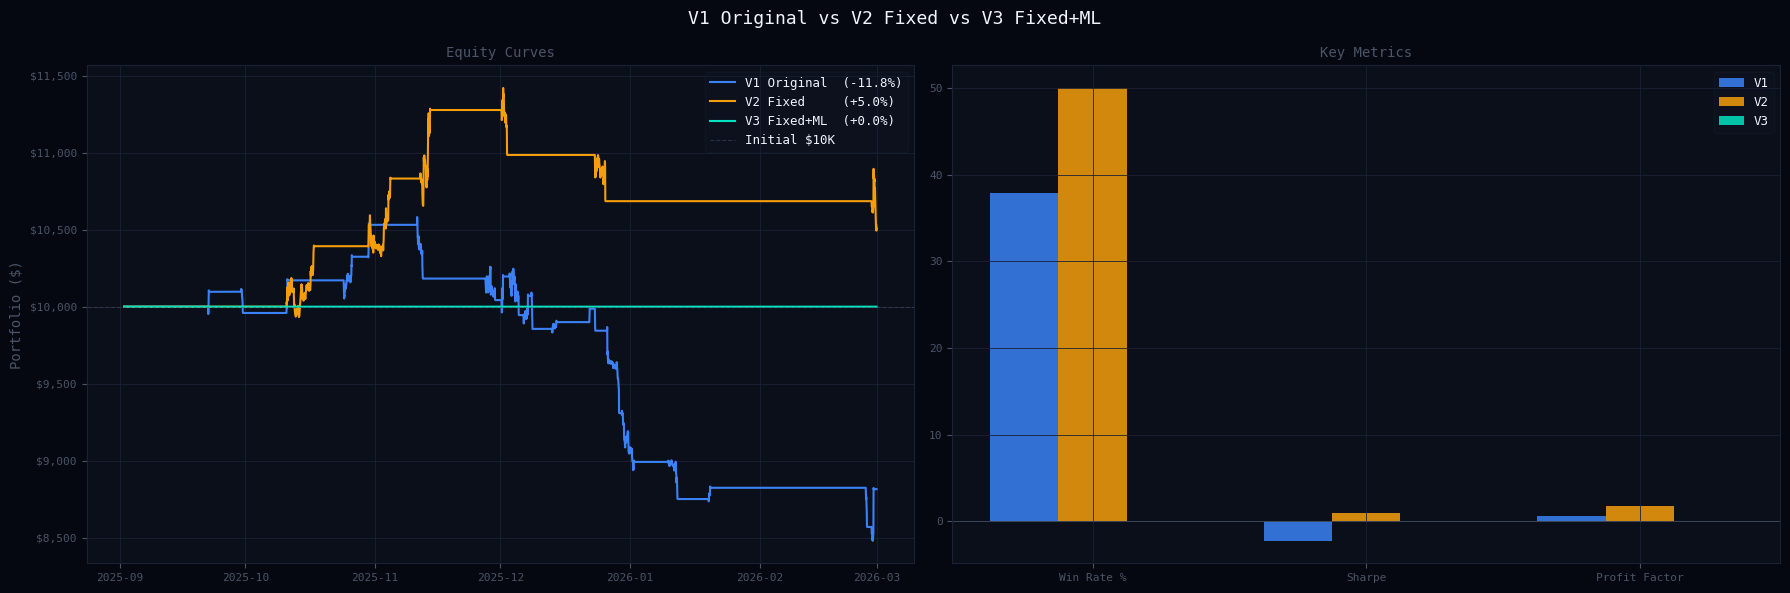


  METRIC                  V1 Original     V2 Fixed  V3 Fixed+ML
  Total Trades                     29            6            0
  Win Rate %                    37.9%        50.0%         0.0%
  Total Return                -11.84%        5.00%        0.00%
  Sharpe Ratio                  -2.21         0.99         0.00
  Max Drawdown                -19.85%       -8.11%        0.00%
  Profit Factor                  0.62         1.73         0.00
  Expectancy                  $-31.74       $90.86        $0.00


In [22]:
if len(X)>=6:
    fig,axes=plt.subplots(1,2,figsize=(18,6))
    fig.patch.set_facecolor('#060811')
    fig.suptitle('V1 Original vs V2 Fixed vs V3 Fixed+ML',color=WHITE,fontsize=13)

    ax=axes[0]
    for res,col,lbl in [
        (result_v1,BLUE,  f'V1 Original  ({m1["total_return"]:+.1f}%)'),
        (result_v2,YELLOW,f'V2 Fixed     ({m2["total_return"]:+.1f}%)'),
        (result_v3,CYAN,  f'V3 Fixed+ML  ({m3["total_return"]:+.1f}%)'),
    ]:
        eq=res['equity']['equity']
        ax.plot(eq.index,eq.values,color=col,lw=1.5,label=lbl)
    ax.axhline(10000,color=GRAY,lw=0.8,ls='--',alpha=0.5,label='Initial $10K')
    ax.set_title('Equity Curves',color=GRAY,fontsize=10)
    ax.set_ylabel('Portfolio ($)',color=GRAY)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'${x:,.0f}'))
    ax.legend(framealpha=0.3)

    ax2=axes[1]
    metric_names=['Win Rate %','Sharpe','Profit Factor']
    v1v=[m1['win_rate'],m1['sharpe_ratio'],m1['profit_factor']]
    v2v=[m2['win_rate'],m2['sharpe_ratio'],m2['profit_factor']]
    v3v=[m3['win_rate'],m3['sharpe_ratio'],m3['profit_factor']]
    x=np.arange(len(metric_names)); w=0.25
    ax2.bar(x-w,  v1v,w,color=BLUE,  alpha=0.85,label='V1')
    ax2.bar(x,    v2v,w,color=YELLOW,alpha=0.85,label='V2')
    ax2.bar(x+w,  v3v,w,color=CYAN,  alpha=0.85,label='V3')
    ax2.set_xticks(x); ax2.set_xticklabels(metric_names,color=GRAY)
    ax2.set_title('Key Metrics',color=GRAY,fontsize=10)
    ax2.axhline(0,color=GRAY,lw=0.5); ax2.legend(framealpha=0.3)
    plt.tight_layout(); plt.show()

    print('\n'+'='*64)
    print(f"  {'METRIC':<22} {'V1 Original':>12} {'V2 Fixed':>12} {'V3 Fixed+ML':>12}")
    print('='*64)
    for label,key,fmt in [
        ('Total Trades',  'total_trades',  '{:.0f}'),
        ('Win Rate %',    'win_rate',      '{:.1f}%'),
        ('Total Return',  'total_return',  '{:.2f}%'),
        ('Sharpe Ratio',  'sharpe_ratio',  '{:.2f}'),
        ('Max Drawdown',  'max_drawdown',  '{:.2f}%'),
        ('Profit Factor', 'profit_factor', '{:.2f}'),
        ('Expectancy',    'expectancy',    '${:.2f}'),
    ]:
        v1=fmt.format(m1.get(key,0))
        v2=fmt.format(m2.get(key,0))
        v3=fmt.format(m3.get(key,0))
        print(f"  {label:<22} {v1:>12} {v2:>12} {v3:>12}")
    print('='*64)

## Cell 14 — Summary

In [23]:
print('='*55)
print('  ALGOTRADE PRO — BACKTEST COMPLETE')
print('='*55)
print('  ✅ V1 — Raw EMA 50/200 crossover')
print('  ✅ V2 — ATR 3.5x + EMA Spread + RSI filter')
print('  ✅ V3 — V2 + ML signal classifier')
print()
print('  NEXT STEPS:')
print('  → Optimize parameters (grid search)')
print('  → Add trailing stop loss')
print('  → Add more strategies (MACD, Bollinger)')
print('  → Connect Binance API for live paper trading')
print('='*55)

  ALGOTRADE PRO — BACKTEST COMPLETE
  ✅ V1 — Raw EMA 50/200 crossover
  ✅ V2 — ATR 3.5x + EMA Spread + RSI filter
  ✅ V3 — V2 + ML signal classifier

  NEXT STEPS:
  → Optimize parameters (grid search)
  → Add trailing stop loss
  → Add more strategies (MACD, Bollinger)
  → Connect Binance API for live paper trading
